Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset path: /kaggle/input/creditcardfraud
(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


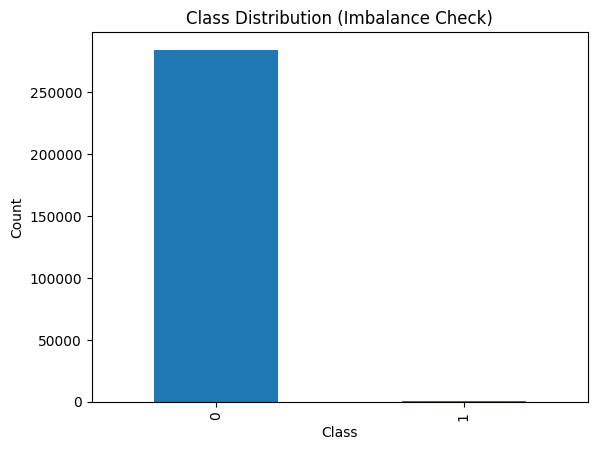

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Train shape: (227845, 29)
Test shape: (56962, 29)
Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64
Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

ROC-AUC: 0.9700
PR-AUC: 0.7667
Random Forest Results:
              pr

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:58:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.69      0.87      0.77        98

    accuracy                           1.00     56962
   macro avg       0.84      0.93      0.88     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9753
PR-AUC: 0.8736


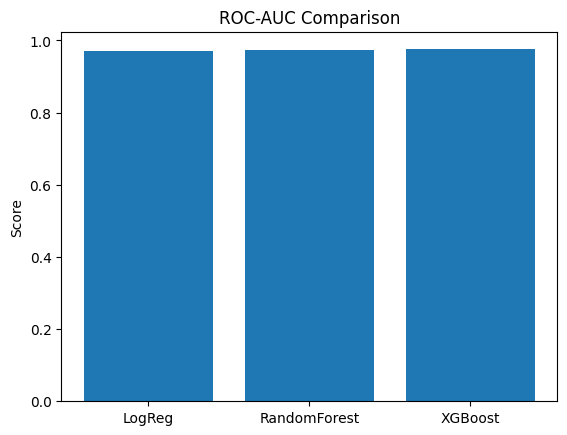

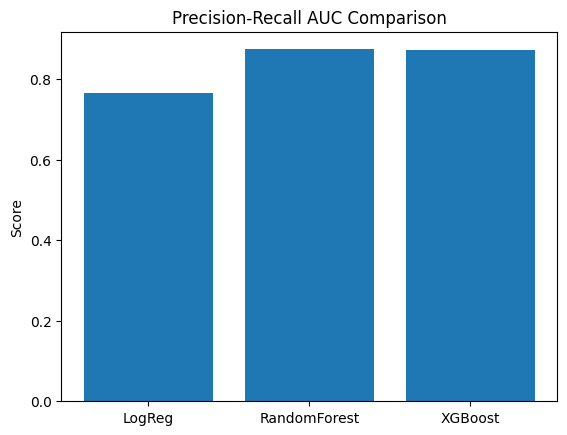

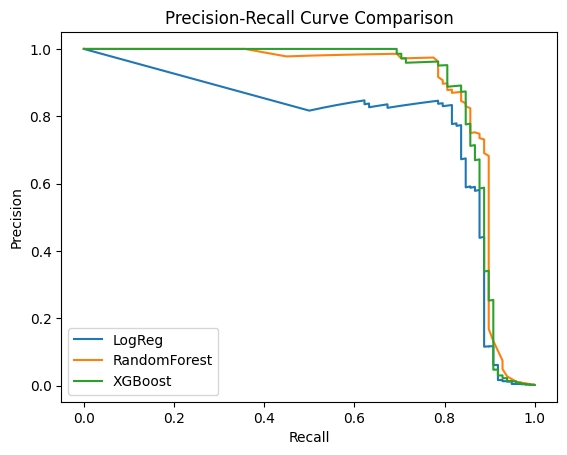

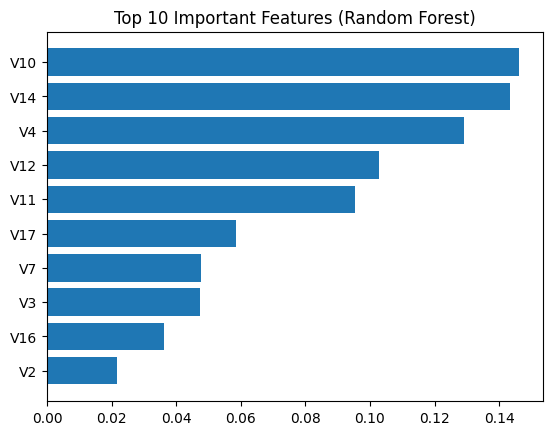

In [ ]:
# Install required libraries
!pip install kagglehub imbalanced-learn xgboost

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

"""**Download Dataset**"""

import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Dataset path:", path)

# Load dataset
df = pd.read_csv(f"{path}/creditcard.csv")
df.head()

"""**Data Exploration**"""

print(df.shape)
print(df['Class'].value_counts())

# Class distribution plot
df['Class'].value_counts().plot(kind='bar')
plt.title("Class Distribution (Imbalance Check)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Check missing values
print(df.isnull().sum())

# Check basic statistics
df.describe()

"""**Feature Scaling**"""

# Scale Amount feature only (Time often ignored)
scaler = StandardScaler()
df['Scaled_Amount'] = scaler.fit_transform(df[['Amount']])

# Drop original Amount and Time
df = df.drop(['Amount', 'Time'], axis=1)

"""**Train-Test Split**"""

X = df.drop('Class', axis=1)
y = df['Class']

# Stratified split due to imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

"""**Handle Class Imbalance (SMOTE)**"""

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

"""**Helper Function for Evaluation**"""

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, y_pred))

    roc = roc_auc_score(y_test, y_prob)

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)

    print(f"ROC-AUC: {roc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")

    return roc, pr_auc

# Logistic Regression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_res, y_train_res)

print("Logistic Regression Results:")
lr_roc, lr_pr = evaluate_model(lr, X_test, y_test)

# Random Forest

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train_res, y_train_res)

print("Random Forest Results:")
rf_roc, rf_pr = evaluate_model(rf, X_test, y_test)

# XGBoost

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb.fit(X_train_res, y_train_res)

print("XGBoost Results:")
xgb_roc, xgb_pr = evaluate_model(xgb, X_test, y_test)

"""**Model Comparison Visualization**"""

models = ['LogReg', 'RandomForest', 'XGBoost']
roc_scores = [lr_roc, rf_roc, xgb_roc]
pr_scores = [lr_pr, rf_pr, xgb_pr]

# ROC Comparison
plt.figure()
plt.bar(models, roc_scores)
plt.title("ROC-AUC Comparison")
plt.ylabel("Score")
plt.show()

# PR-AUC Comparison (Important for imbalance)
plt.figure()
plt.bar(models, pr_scores)
plt.title("Precision-Recall AUC Comparison")
plt.ylabel("Score")
plt.show()

# Precision-Recall Curve

plt.figure()

for model, name in zip([lr, rf, xgb], models):
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

# Feature Importance

importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top 10 Important Features (Random Forest)")
plt.show()